# Clustering K-means vs Gaussian Mixture : Practice & Experiments

Here, we will compare K-means and the Gaussian Mixture Model (GMM) on the Iris dataset

## Imports

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [41]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [42]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
from sklearn.metrics.cluster import contingency_matrix

## Data

In [43]:
iris = datasets.load_iris()
X = iris.data  
y = iris.target
feature_names = iris.feature_names
label_names = iris.target_names

In [44]:
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [45]:
print(label_names)

['setosa' 'versicolor' 'virginica']


In [46]:
def show_data(X, y, features=[0, 1], feature_names=feature_names):
    '''Display the samples in 2D'''
    plt.figure(figsize=(5,5))
    for label in set(y):
        plt.scatter(X[y == label, features[0]], X[y == label, features[1]])
    plt.xlabel(feature_names[features[0]])
    plt.ylabel(feature_names[features[1]])
    plt.show()

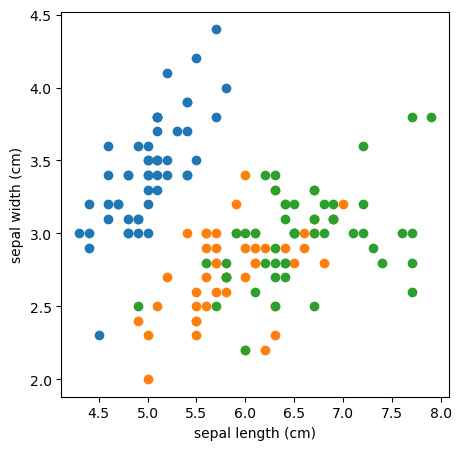

In [47]:
show_data(X, y, [0, 1])

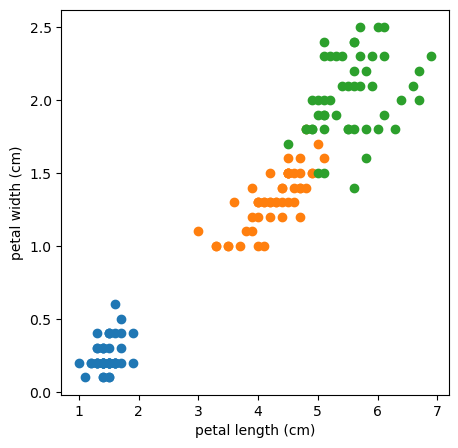

In [48]:
show_data(X, y, [2, 3])

## K-means

We first apply k-means and display the clusters.

In [49]:
n_clusters = 3
km = KMeans(n_clusters, n_init=10)
labels = km.fit_predict(X)

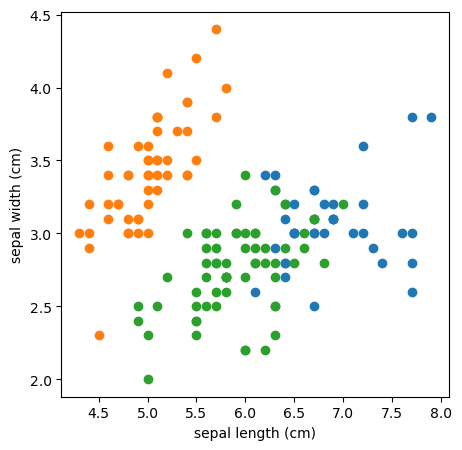

In [50]:
show_data(X, labels, [0, 1])

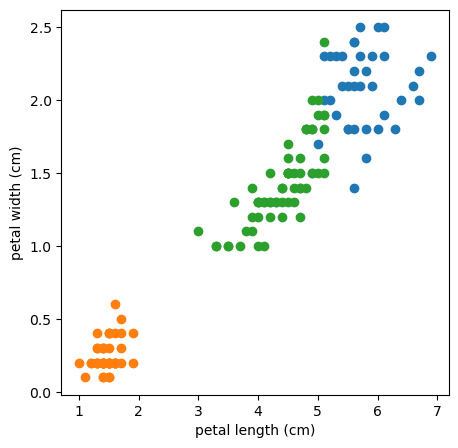

In [51]:
show_data(X, labels, [2, 3])

## Gaussian Mixture Model

We now compare with the Gaussian Mixture Model.

In [52]:
gm = GaussianMixture(n_clusters)
labels_ = gm.fit_predict(X)

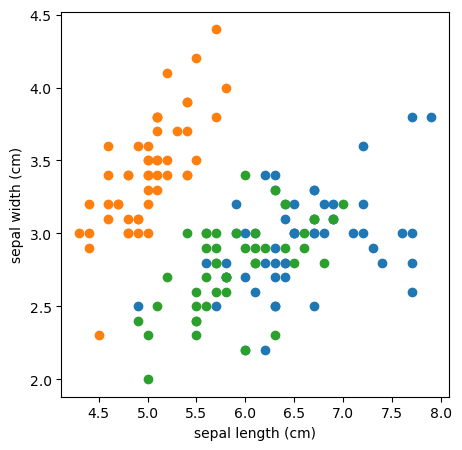

In [53]:
show_data(X, labels_, [0, 1])

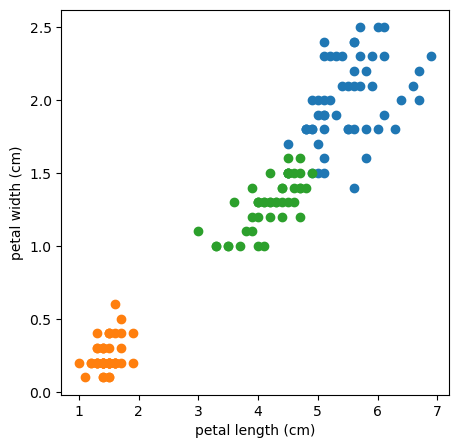

In [54]:
show_data(X, labels_, [2, 3])

## To do

* Display the contigency matrix for each clustering. Which one looks better?
* Confirm your guess using the ARI and AMI scores.
* Check that the optimal number of clusters is 3.
* Is it possible to guess the optimal number of clusters with the silhouette scores?<br>
Interpret the results.

Contingency Matrix for KMeans (3 Clusters):
[[ 0 50  0]
 [ 2  0 48]
 [36  0 14]]

Contingency Matrix for GMM (3 Clusters):
[[ 0 50  0]
 [ 5  0 45]
 [50  0  0]]

ARI (KMeans, 3 clusters): 0.7302382722834697
ARI (GMM, 3 clusters): 0.9038742317748124

AMI (KMeans, 3 clusters): 0.7551191675800485
AMI (GMM, 3 clusters): 0.89843610336763


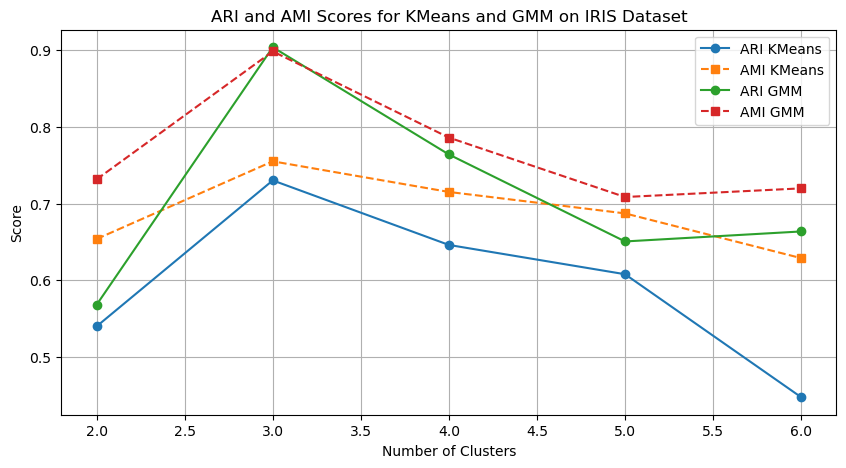

In [ ]:
cluster_range = range(2, 7)  
ari_scores_kmeans = []
ami_scores_kmeans = []
ari_scores_gmm = []
ami_scores_gmm = []

# Compare KMeans and GMM with 3 clusters
contingency_kmeans = contingency_matrix(y, labels)
contingency_gmm = contingency_matrix(y, labels_)

print("Contingency Matrix for KMeans (3 Clusters):")
print(contingency_kmeans)
print("\nContingency Matrix for GMM (3 Clusters):")
print(contingency_gmm)

print("\nARI (KMeans, 3 clusters):", adjusted_rand_score(y, labels))
print("ARI (GMM, 3 clusters):", adjusted_rand_score(y, labels_))
print("\nAMI (KMeans, 3 clusters):", adjusted_mutual_info_score(y, labels))
print("AMI (GMM, 3 clusters):", adjusted_mutual_info_score(y, labels_))

# Perform clustering and compute ARI & AMI scores for varying cluster numbers
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    gmm = GaussianMixture(n_components=k)
    
    y_pred_kmeans = kmeans.fit_predict(X)
    y_pred_gmm = gmm.fit_predict(X)
    
    ari_scores_kmeans.append(adjusted_rand_score(y, y_pred_kmeans))
    ami_scores_kmeans.append(adjusted_mutual_info_score(y, y_pred_kmeans))
    ari_scores_gmm.append(adjusted_rand_score(y, y_pred_gmm))
    ami_scores_gmm.append(adjusted_mutual_info_score(y, y_pred_gmm))

# Plot ARI and AMI scores
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, ari_scores_kmeans, marker='o', linestyle='-', label='ARI KMeans')
plt.plot(cluster_range, ami_scores_kmeans, marker='s', linestyle='--', label='AMI KMeans')
plt.plot(cluster_range, ari_scores_gmm, marker='o', linestyle='-', label='ARI GMM')
plt.plot(cluster_range, ami_scores_gmm, marker='s', linestyle='--', label='AMI GMM')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("ARI and AMI Scores for KMeans and GMM on IRIS Dataset")
plt.legend()
plt.grid(True)
plt.show()

## Variants

Some constraints can be added on the covariance matrices so as to make the model simpler and less prone to overfitting.

In [56]:
gm = GaussianMixture(n_clusters, covariance_type='spherical')

## To do 

* Test the various types of covariance matrices and interpret the results.
* Redo the experiments with a scaling factor of 10 on ones of the 4 components and interpret the results.

In [57]:
X_scale = X.copy()
X_scale[:, 0] *= 10

In [58]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Ellipse
from scipy.spatial.transform import Rotation as R

In [59]:
def plot_sphere_3d(ax, mean, variances, scale=1.0):
    """Plots a 3D sphere to represent isotropic covariance matrices."""
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    
    scales = scale * np.sqrt(variances)
    x, y, z = scales[0] * x + mean[0], scales[1] * y + mean[1], scales[2] * z + mean[2]
    
    ax.plot_wireframe(x, y, z, color='black', alpha=0.3, linewidth=0.5)

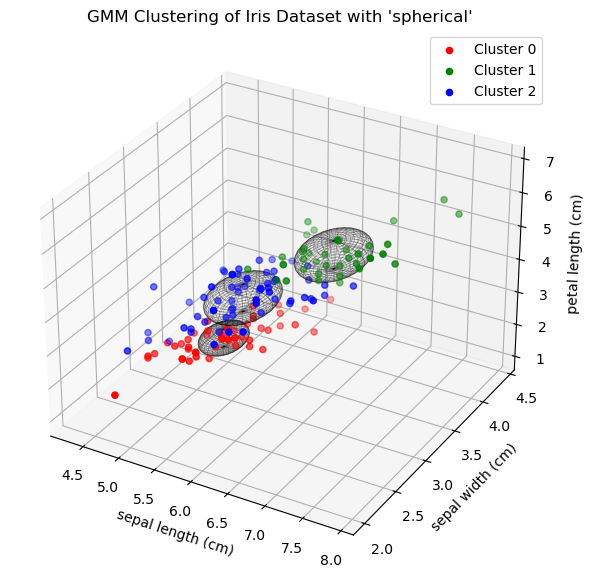

In [60]:
gm = GaussianMixture(n_clusters, covariance_type='spherical')
gm.fit(X)
labels_ = gm.fit_predict(X)

# Plot 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b']

for i in range(n_clusters):
    cluster_data = X[labels_ == i]
    ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2], c=colors[i], label=f'Cluster {i}')
    
    # Plot covariance ellipsoid
    plot_sphere_3d(ax, gm.means_[i], gm.covariances_[i] * np.ones((4,)))

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.legend()
plt.title("GMM Clustering of Iris Dataset with 'spherical'")
plt.show()

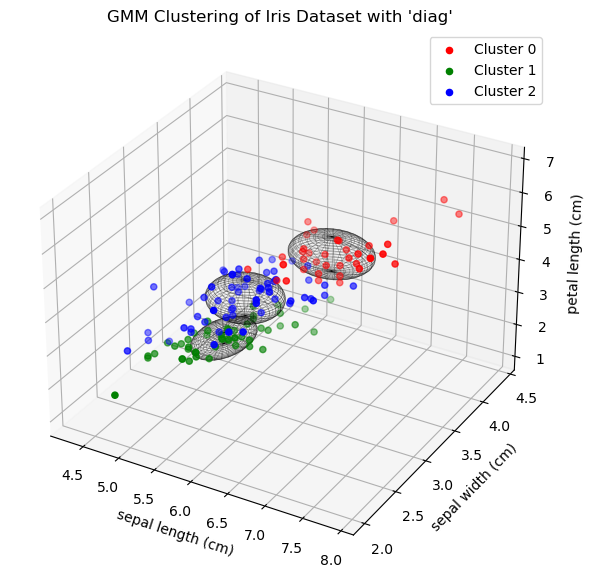

In [61]:
gm = GaussianMixture(n_clusters, covariance_type='diag')
gm.fit(X)
labels_ = gm.fit_predict(X)

# Plot 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b']

for i in range(n_clusters):
    cluster_data = X[labels == i]
    ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2], c=colors[i], label=f'Cluster {i}')
    
    # Plot covariance ellipsoid
    plot_sphere_3d(ax, gm.means_[i], gm.covariances_[i])

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.legend()
plt.title("GMM Clustering of Iris Dataset with 'diag'")
plt.show()

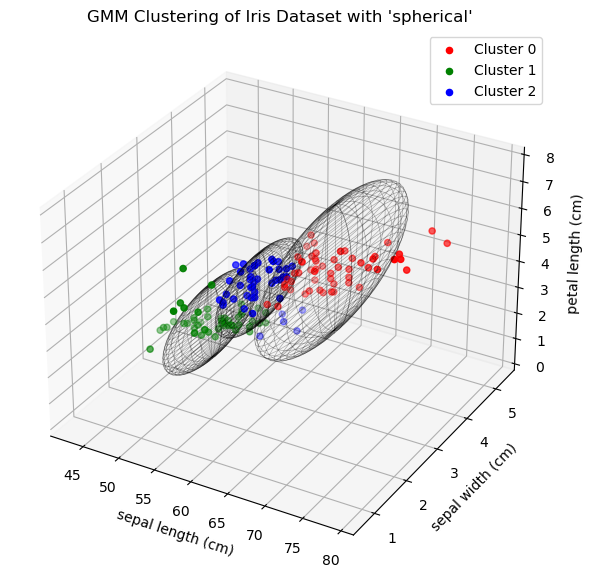

In [63]:
gm = GaussianMixture(n_clusters, covariance_type='spherical')
gm.fit(X_scale)
labels_ = gm.fit_predict(X_scale)

# Plot 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b']

for i in range(n_clusters):
    cluster_data = X_scale[labels_ == i]
    ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2], c=colors[i], label=f'Cluster {i}')
    
    # Plot covariance ellipsoid
    plot_sphere_3d(ax, gm.means_[i], gm.covariances_[i] * np.ones((4,)))

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.legend()
plt.title("GMM Clustering of Iris Dataset with 'spherical'")
plt.show()

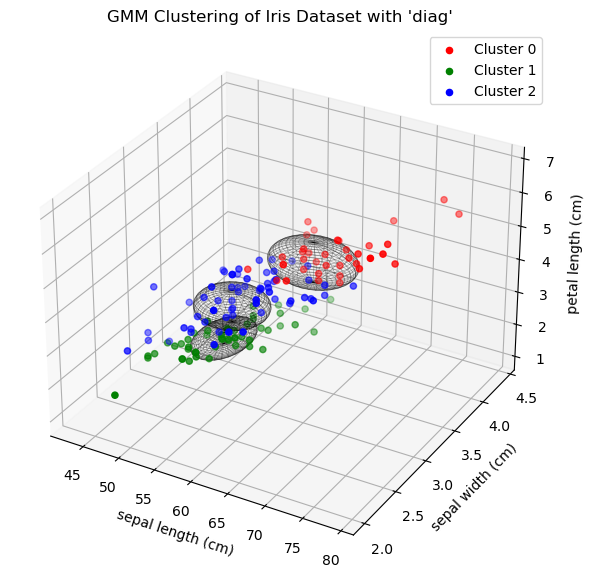

In [64]:
gm = GaussianMixture(n_clusters, covariance_type='diag')
gm.fit(X_scale)
labels_ = gm.fit_predict(X_scale)

# Plot 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b']

for i in range(n_clusters):
    cluster_data = X_scale[labels == i]
    ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2], c=colors[i], label=f'Cluster {i}')
    
    # Plot covariance ellipsoid
    plot_sphere_3d(ax, gm.means_[i], gm.covariances_[i])

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.legend()
plt.title("GMM Clustering of Iris Dataset with 'diag'")
plt.show()